### Imports

In [1]:
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.ensemble import IsolationForest

In [2]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

### Load dataset and perform EDA

In [3]:
pd.set_option("display.max_columns", None)
d = pd.read_csv("data/breastcancer.csv").drop_duplicates()  # doesnt load duplicates

In [4]:
print(d.shape)

(569, 32)


In [5]:
d.sample(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
21,8510824,B,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.02076,0.1815,0.06905,0.2773,0.9768,1.909,15.700,0.009606,0.01432,0.01985,0.014210,0.02027,0.002968,10.230,15.66,65.13,314.9,0.1324,0.1148,0.08867,0.06227,0.2450,0.07773
523,917896,B,13.710,18.68,88.73,571.0,0.09916,0.10700,0.05385,0.03783,0.1714,0.06843,0.3191,1.2490,2.284,26.450,0.006739,0.02251,0.02086,0.013520,0.01870,0.003747,15.110,25.63,99.43,701.9,0.1425,0.2566,0.19350,0.12840,0.2849,0.09031
228,88147202,B,12.620,23.97,81.35,496.4,0.07903,0.07529,0.05438,0.02036,0.1514,0.06019,0.2449,1.0660,1.445,18.510,0.005169,0.02294,0.03016,0.008691,0.01365,0.003407,14.200,31.31,90.67,624.0,0.1227,0.3454,0.39110,0.11800,0.2826,0.09585
114,864496,B,8.726,15.83,55.84,230.9,0.11500,0.08201,0.04132,0.01924,0.1649,0.07633,0.1665,0.5864,1.354,8.966,0.008261,0.02213,0.03259,0.010400,0.01708,0.003806,9.628,19.62,64.48,284.4,0.1724,0.2364,0.24560,0.10500,0.2926,0.10170
531,91903901,B,11.670,20.02,75.21,416.2,0.10160,0.09453,0.04200,0.02157,0.1859,0.06461,0.2067,0.8745,1.393,15.340,0.005251,0.01727,0.01840,0.005298,0.01449,0.002671,13.350,28.81,87.00,550.6,0.1550,0.2964,0.27580,0.08120,0.3206,0.08950


In [6]:
print(d.isnull().sum())  # no null

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [7]:
print(d.dtypes)  # id not needed, diagnosis needs to be onehot encoded

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [8]:
# One hot encoding
dum = pd.get_dummies(d["diagnosis"], dtype=int)
df = pd.concat([d, dum], axis=1)

# remove unneeded after onehot encoding
df = df.drop(columns=["id", "B", "diagnosis"])

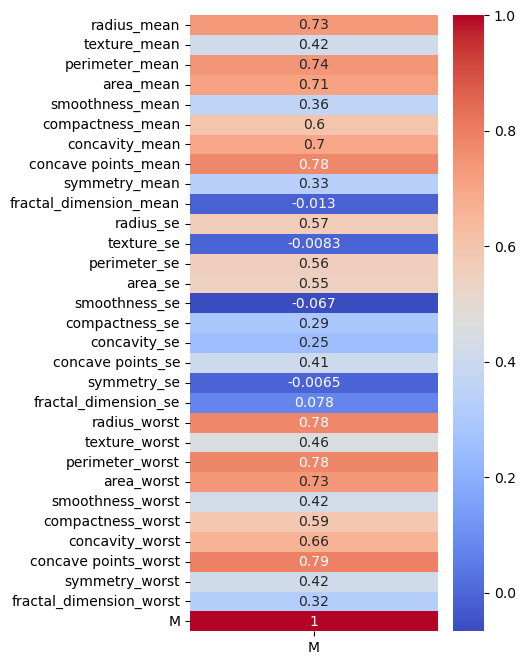

In [9]:
plt.figure(figsize=(4, 8))
sns.heatmap(df.corr()[["M"]], cmap="coolwarm", annot=True)
plt.show()
# many low correlation features

In [10]:
# dropped very low correlation columns <|0.01|
df = df.drop(
    columns=[
        "texture_se",
        "smoothness_se",
        "symmetry_se",
        "fractal_dimension_se",
        "fractal_dimension_mean",
    ]
)

In [11]:
df.describe()  # looks skewed, so cant use standardscalar

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,radius_se,perimeter_se,area_se,compactness_se,concavity_se,concave points_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,M
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.405172,2.866059,40.337079,0.025478,0.031894,0.011796,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.277313,2.021855,45.491006,0.017908,0.030186,0.006170,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.111500,0.757000,6.802000,0.002252,0.000000,0.000000,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.232400,1.606000,17.850000,0.013080,0.015090,0.007638,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.324200,2.287000,24.530000,0.020450,0.025890,0.010930,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.478900,3.357000,45.190000,0.032450,0.042050,0.014710,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,2.873000,21.980000,542.200000,0.135400,0.396000,0.052790,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [12]:
df.skew()  # most data seems highly right skewed

radius_mean                0.942380
texture_mean               0.650450
perimeter_mean             0.990650
area_mean                  1.645732
smoothness_mean            0.456324
compactness_mean           1.190123
concavity_mean             1.401180
concave points_mean        1.171180
symmetry_mean              0.725609
radius_se                  3.088612
perimeter_se               3.443615
area_se                    5.447186
compactness_se             1.902221
concavity_se               5.110463
concave points_se          1.444678
radius_worst               1.103115
texture_worst              0.498321
perimeter_worst            1.128164
area_worst                 1.859373
smoothness_worst           0.415426
compactness_worst          1.473555
concavity_worst            1.150237
concave points_worst       0.492616
symmetry_worst             1.433928
fractal_dimension_worst    1.662579
M                          0.528461
dtype: float64

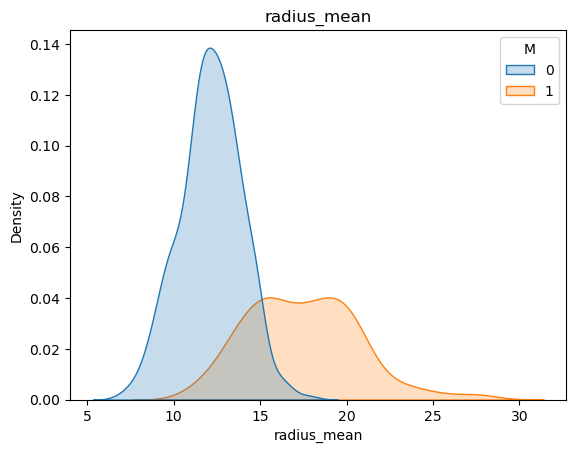

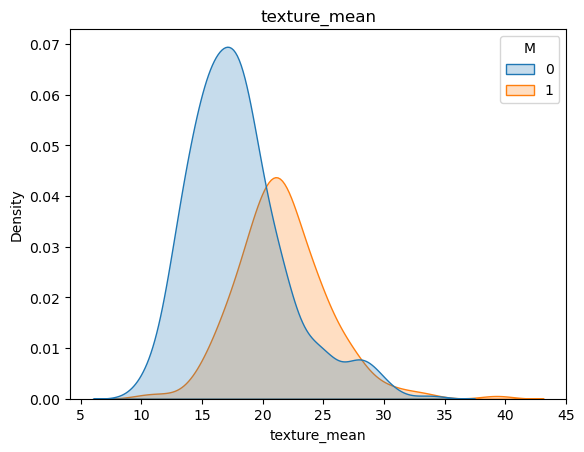

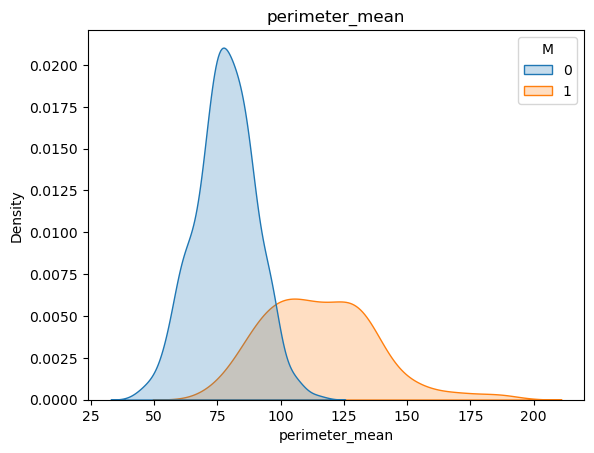

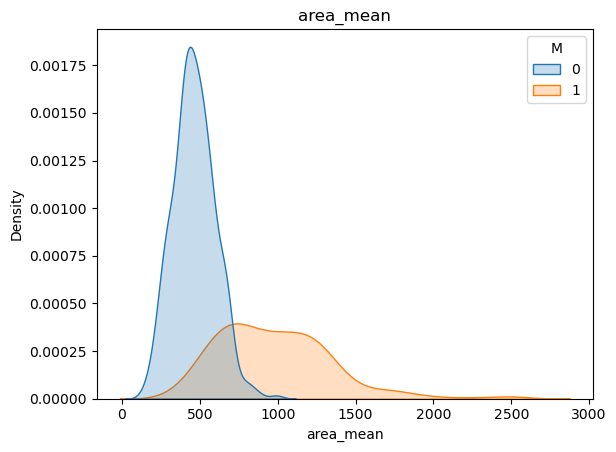

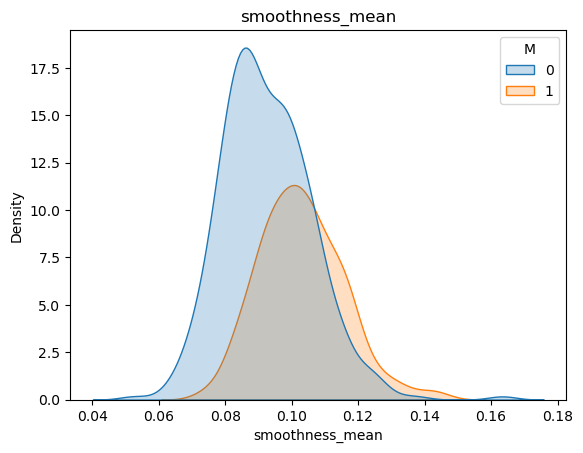

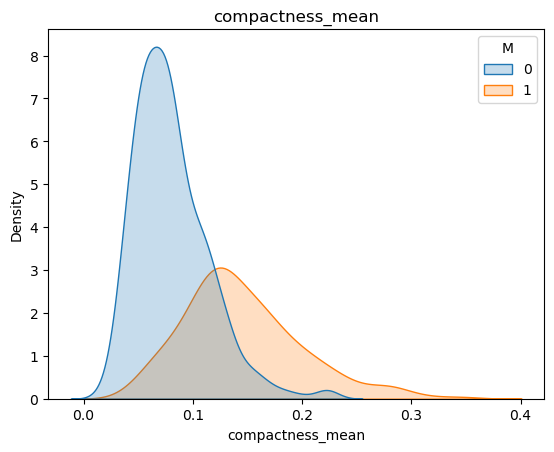

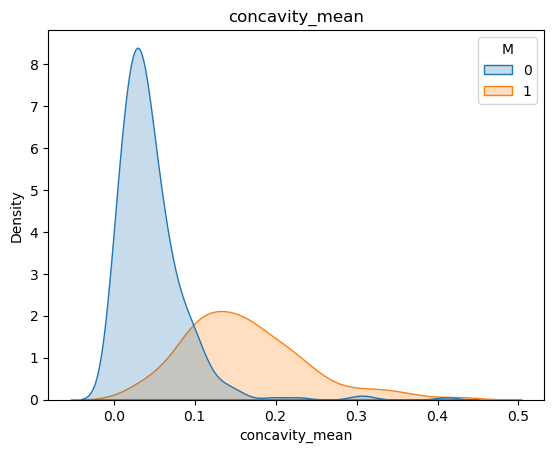

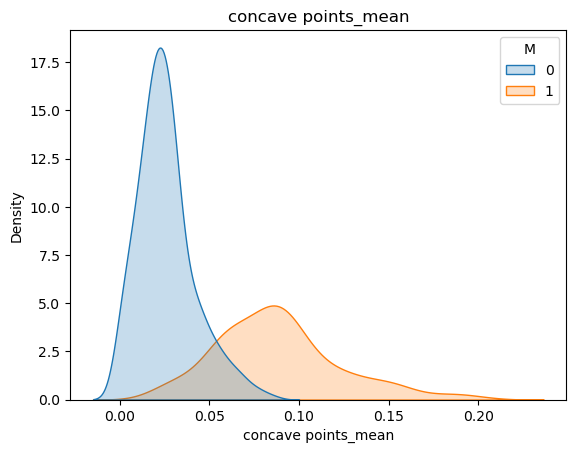

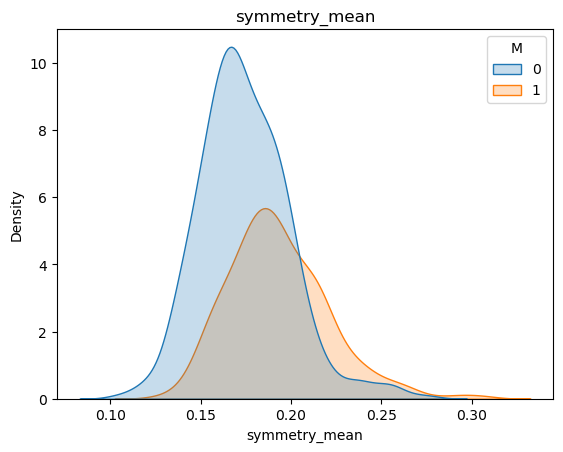

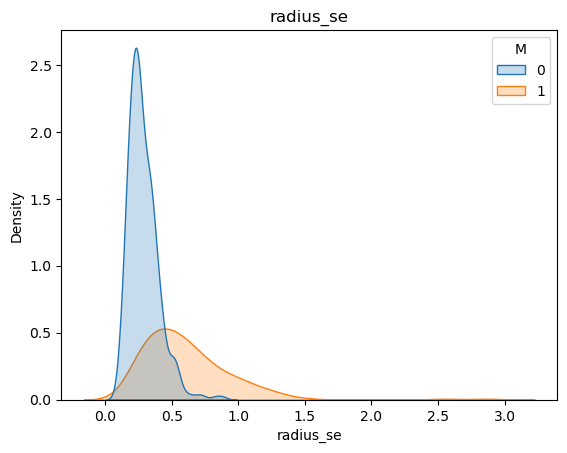

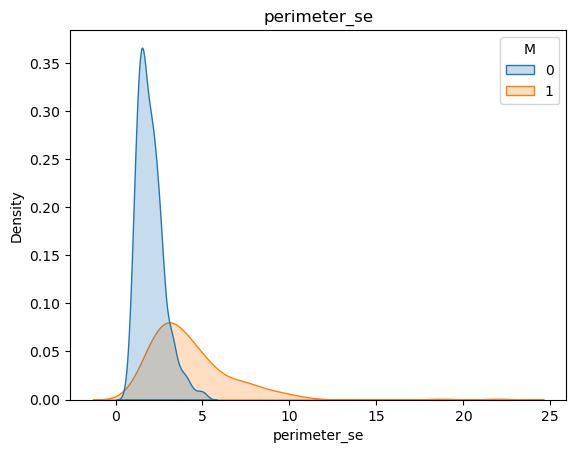

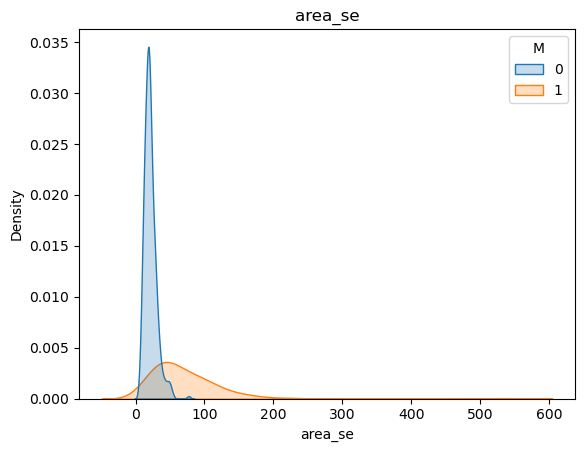

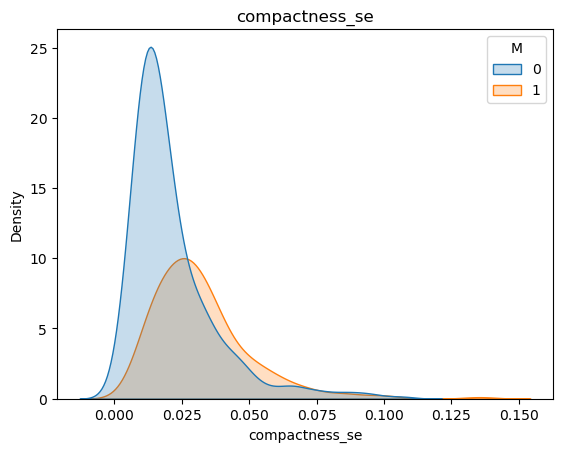

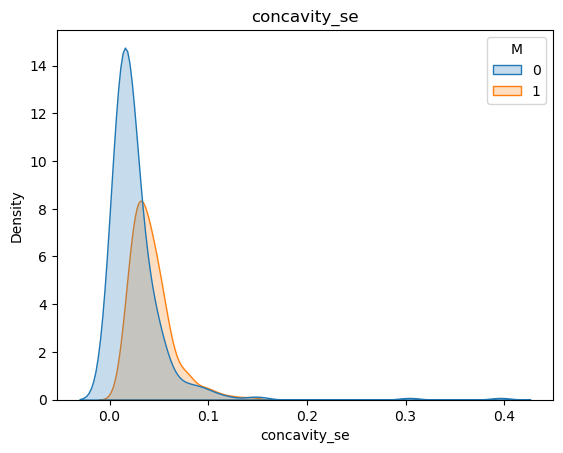

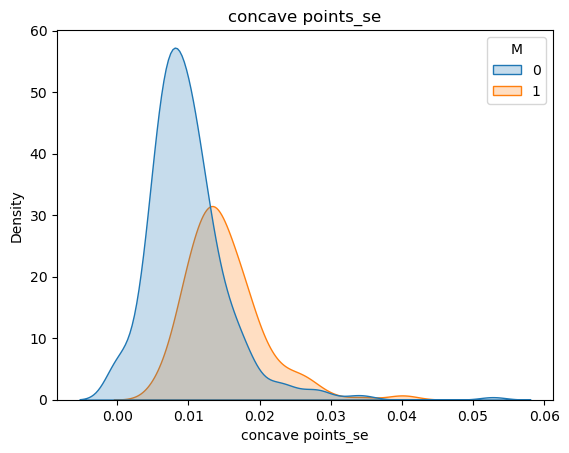

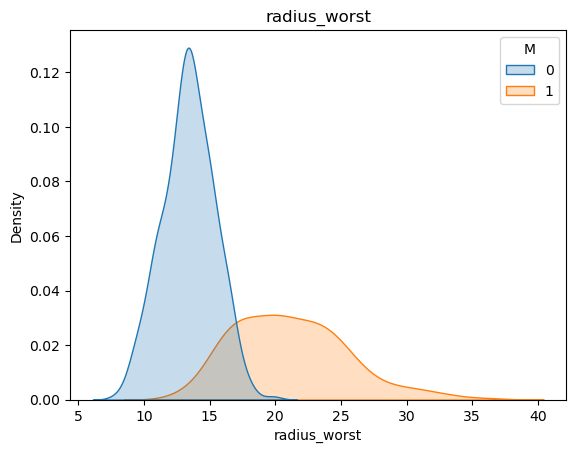

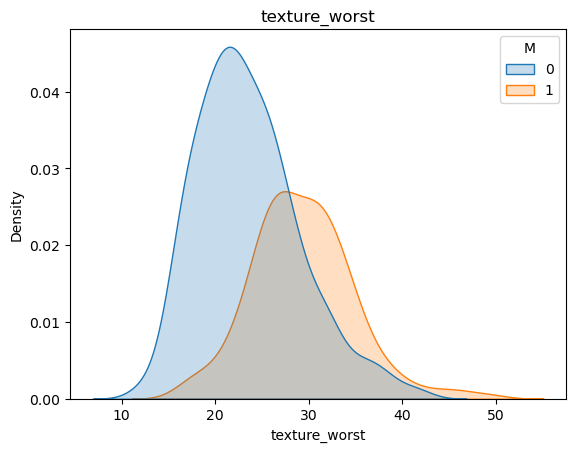

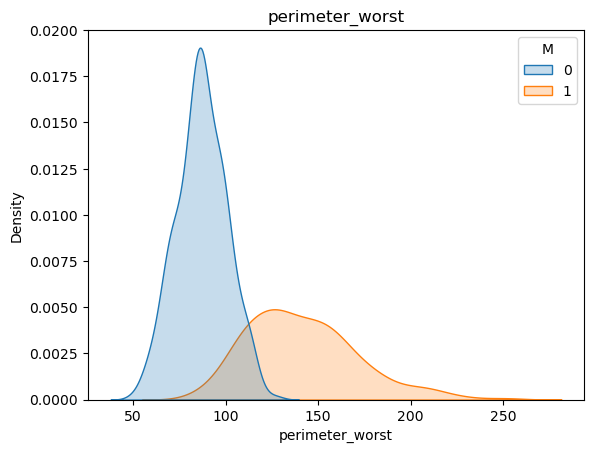

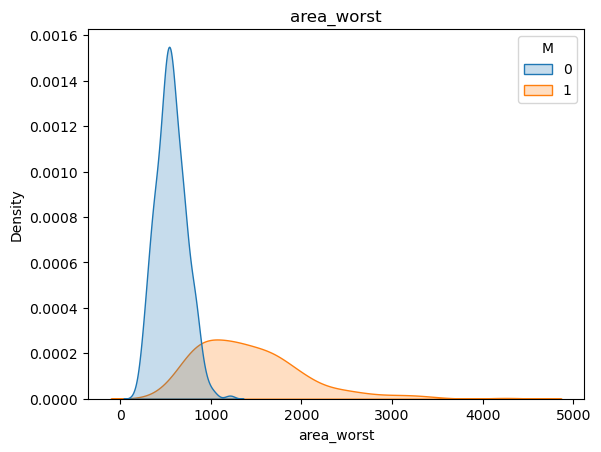

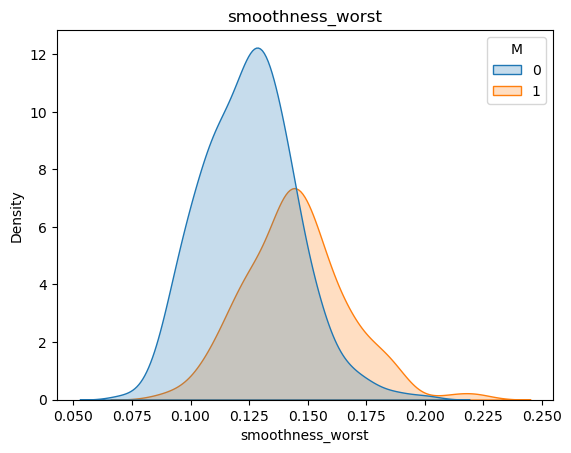

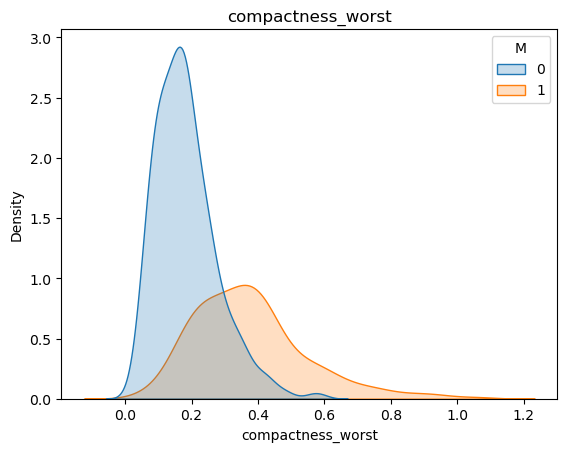

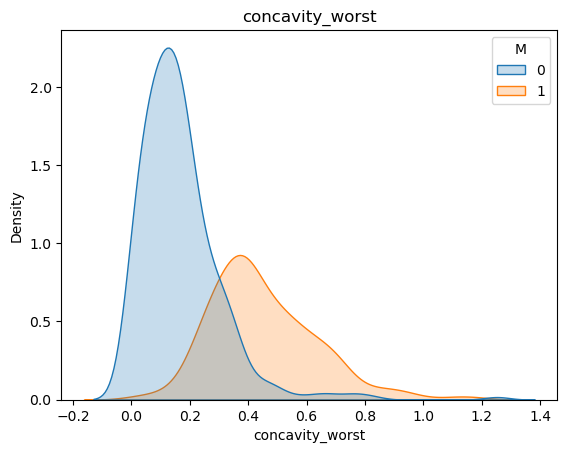

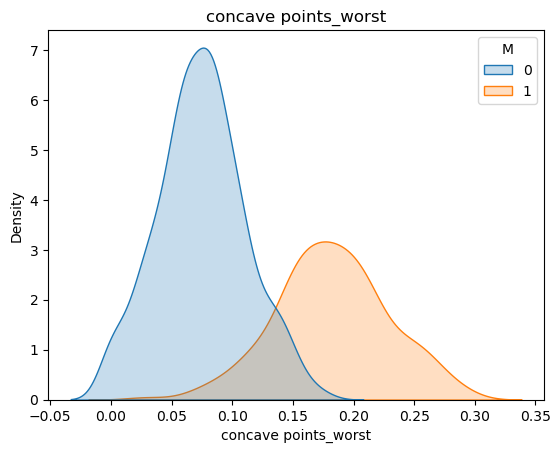

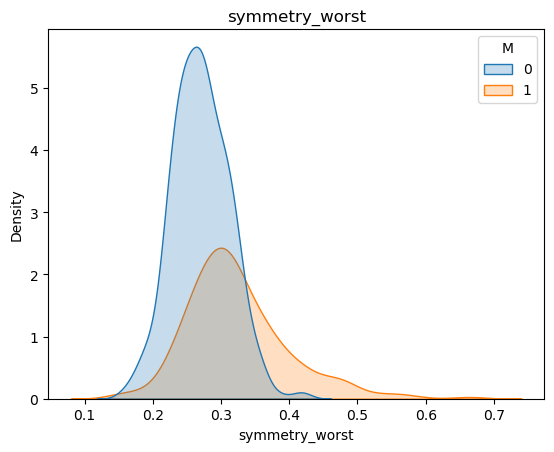

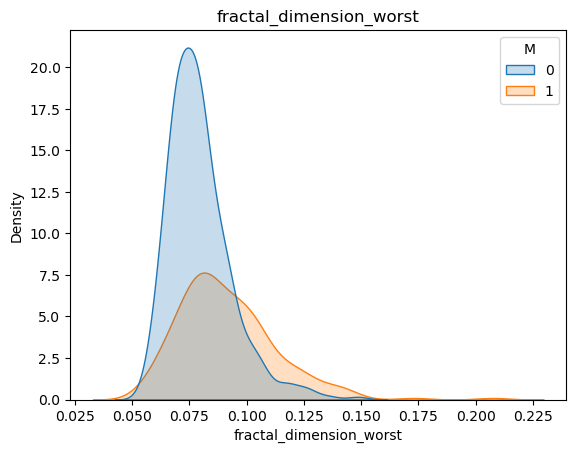

In [13]:
for col in df.columns:
    if col != "M":
        sns.kdeplot(data=df, x=col, hue="M", fill=True)

        plt.title(col)
        plt.show()
# many outliers, but are they needed to tell if its M or not?

##### Removing outliers and splitting data

In [14]:
iso_forest = IsolationForest(contamination=0.07, random_state=42)
# Labels: 1 = inlier, -1 = outlier

In [15]:
y = df["M"]
X = df.drop(columns="M")

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
inliers = iso_forest.fit_predict(X_train)

iX_train = X_train[inliers == 1]
iy_train = y_train[inliers == 1]

### Comparing models with and without outliers

In [18]:
pipea = Pipeline(
    [
        ("scale", PowerTransformer(method="yeo-johnson")),
        ("model", SGDClassifier(eta0=0.0005, max_iter=2300, tol=0.005)),
    ]
)
a = pipea.fit(X_train, y_train)
preda = a.predict(X_test)

In [21]:
sdg = Pipeline(
    [
        ("scale", PowerTransformer(method="yeo-johnson")),
        ("model", SGDClassifier(eta0=0.0005, max_iter=2300, tol=0.005)),
    ]
)
sdg.fit(iX_train, iy_train)
predsdg = sdg.predict(X_test)

In [22]:
print(
    f"no iso = {accuracy_score(y_test, preda)}\niso = {accuracy_score(y_test, predsdg)}"
)
# isolation is better in most runs

no iso = 0.9824561403508771
iso = 0.9736842105263158


### Now the trees

In [23]:
# Trees do not benifit from scaling or removing outliers
rf = RandomForestClassifier()
dt = DecisionTreeClassifier()
xb = XGBClassifier()

In [24]:
rf.fit(X_train, y_train)
dt.fit(X_train, y_train)
xb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [25]:
pred_rf = rf.predict(X_test)
pred_dt = dt.predict(X_test)
pred_xb = xb.predict(X_test)

### Other models

In [26]:
svc = Pipeline([("scale", PowerTransformer(method="yeo-johnson")), ("model", SVC())])
knn = Pipeline(
    [
        ("scale", PowerTransformer(method="yeo-johnson")),
        ("model", KNeighborsClassifier()),
    ]
)
lr = Pipeline(
    [("scale", PowerTransformer(method="yeo-johnson")), ("model", LogisticRegression())]
)
nb = Pipeline(
    [("scale", PowerTransformer(method="yeo-johnson")), ("model", GaussianNB())]
)

In [27]:
svc.fit(iX_train, iy_train)
knn.fit(iX_train, iy_train)
lr.fit(iX_train, iy_train)
nb.fit(iX_train, iy_train)

Pipeline(steps=[('scale', PowerTransformer()), ('model', GaussianNB())])

In [28]:
pred_svc = svc.predict(X_test)
pred_knn = knn.predict(X_test)
pred_lr = lr.predict(X_test)
pred_nb = nb.predict(X_test)

In [29]:
predictions = {
    "SVC": pred_svc,
    "KNN": pred_knn,
    "Logistic Regression": pred_lr,
    "Naive Bayes": pred_nb,
    "Random Forest": pred_rf,
    "Decision Tree": pred_dt,
    "XGBoost": pred_xb,
    "SGD": predsdg,
}

# Calculate metrics for each model
results = []
for model_name, y_pred in predictions.items():
    results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(
                y_test, y_pred, average="weighted", zero_division=0
            ),
            "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
            "F1-Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        }
    )

df_compare = (
    pd.DataFrame(results)
    .sort_values(by="F1-Score", ascending=False)
    .reset_index(drop=True)
)

# best model is consistantly logistic regressor, while the worst is Decision tree
print(df_compare.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.982456   0.982456 0.982456  0.982456
                SGD  0.973684   0.973958 0.973684  0.973742
                SVC  0.973684   0.973719 0.973684  0.973621
                KNN  0.964912   0.964912 0.964912  0.964912
        Naive Bayes  0.956140   0.956488 0.956140  0.956237
      Random Forest  0.956140   0.956088 0.956140  0.956036
            XGBoost  0.956140   0.956088 0.956140  0.956036
      Decision Tree  0.921053   0.921548 0.921053  0.921226


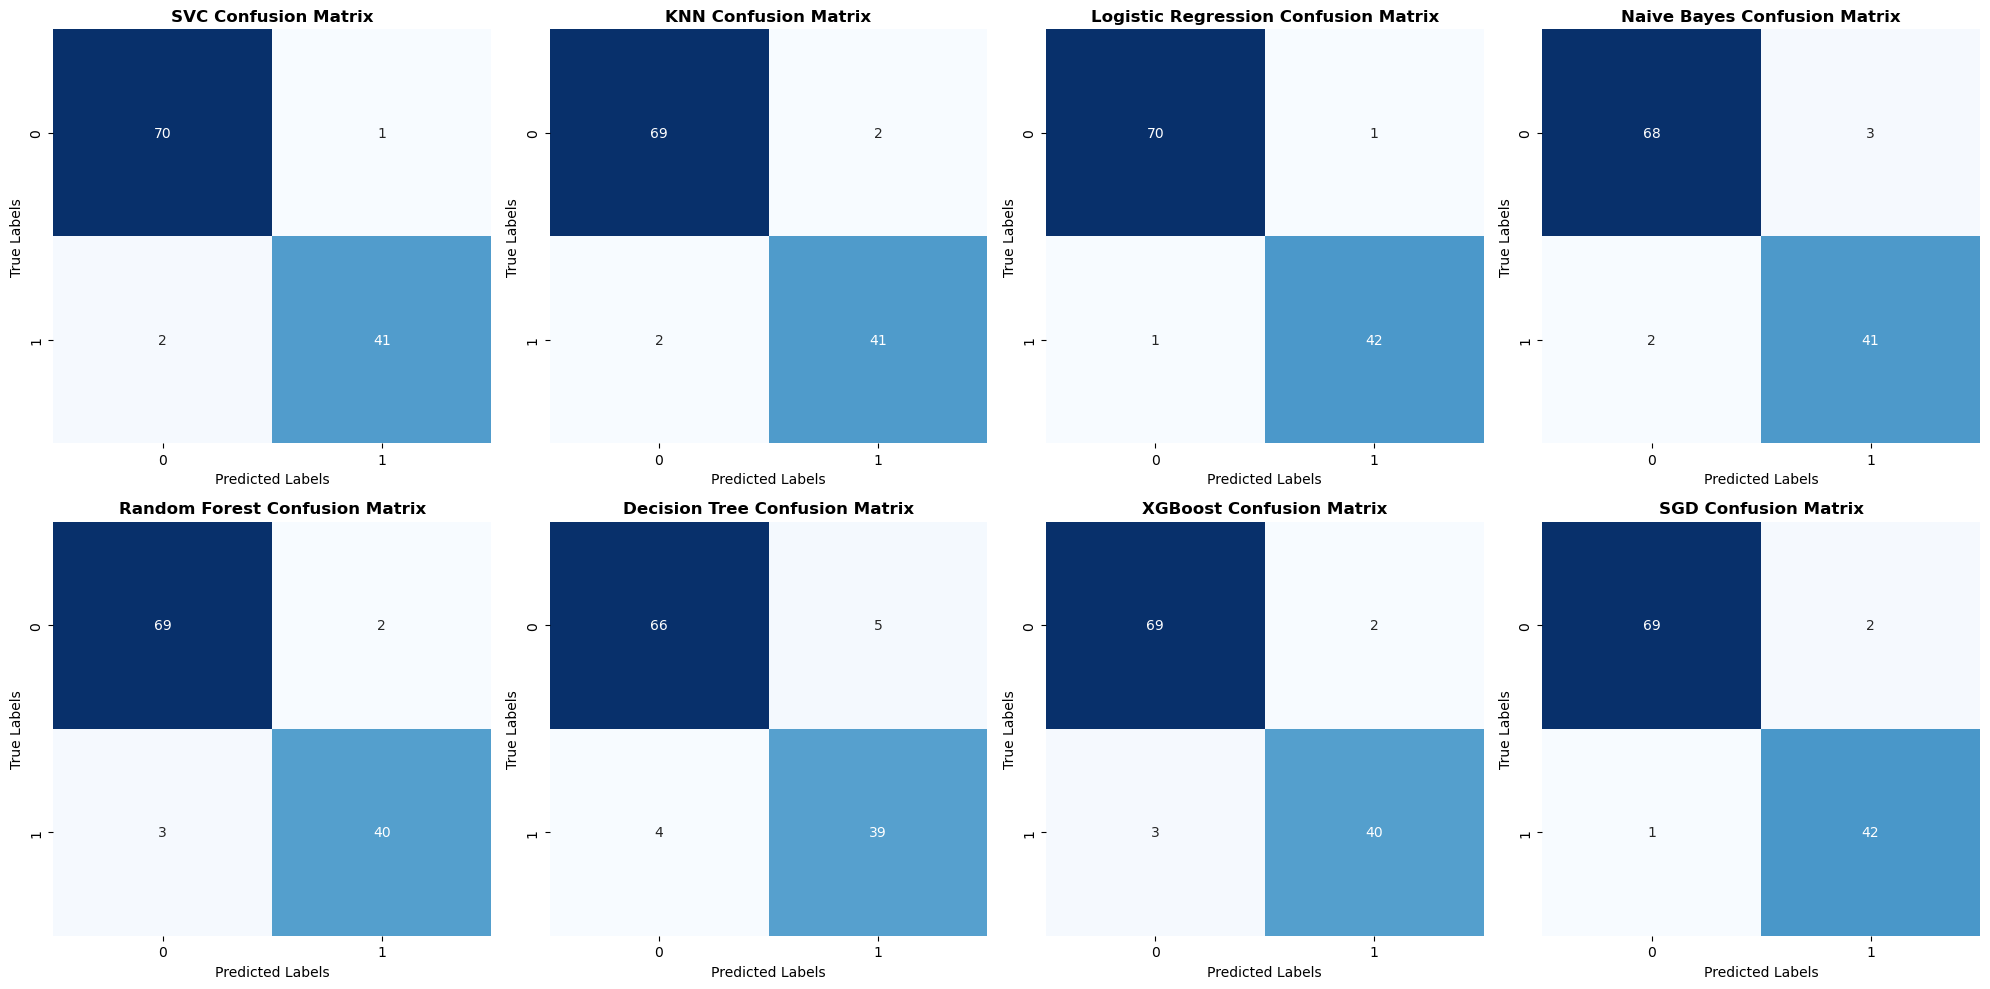

In [30]:
# Compare confusion matrixes
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()


for i, (model_name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i], cbar=False)

    axes[i].set_title(f"{model_name} Confusion Matrix", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Predicted Labels", fontsize=10)
    axes[i].set_ylabel("True Labels", fontsize=10)

plt.tight_layout()
plt.show()

###### Removing outliers is better so pipeb is used

In [32]:
grid = GridSearchCV(
    estimator=sdg,
    param_grid={
        "model__eta0": [0.001, 0.005, 0.0005, 0.002],
        "model__max_iter": [1500, 1700, 2300, 2000],
        "model__tol": [0.001, 0.0001, 0.005, 0.0005],
    },
    scoring="accuracy",
    cv=15,
    n_jobs=-1,
    verbose=1,
)
"""grid.fit(iX_train,iy_train)
grid.best_params_"""

'grid.fit(iX_train,iy_train)\ngrid.best_params_'

In [33]:
import pickle

# Save every model (even dt)

models_dict = {
    "SVC": svc,
    "KNN": knn,
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "Random Forest": rf,
    "Decision Tree": dt,
    "XGBoost": xb,
    "SGD": sdg,
}

for name, model in models_dict.items():
    filename = f"{name}Model.pkl"
    with open(filename, "wb") as f:
        pickle.dump(model, f)
    print(f"Successfully saved: {filename}")

Successfully saved: SVCModel.pkl
Successfully saved: KNNModel.pkl
Successfully saved: Logistic RegressionModel.pkl
Successfully saved: Naive BayesModel.pkl
Successfully saved: Random ForestModel.pkl
Successfully saved: Decision TreeModel.pkl
Successfully saved: XGBoostModel.pkl
Successfully saved: SGDModel.pkl
